In [2]:
import pandas as pd
import numpy as np

# Set random seed for reproducibility
np.random.seed(42)

# Define number of samples
num_samples = 500

# Generate synthetic data
carbon_emissions = np.random.uniform(50, 400, num_samples)  # Emissions in hypothetical units
energy_output = np.random.uniform(100, 1000, num_samples)   # Energy output in hypothetical units
renewability_index = np.random.uniform(0, 1, num_samples)   # Index from 0 (non-renewable) to 1 (fully renewable)
cost_efficiency = np.random.uniform(0.5, 5, num_samples)    # Cost efficiency score

# Generating a binary target variable based on a condition
# This is just an example: high renewability and low emissions favor sustainability
sustainability = [
    1 if (emission < 200 and renewability > 0.5 and cost < 3) else 0
    for emission, renewability, cost in zip(carbon_emissions, renewability_index, cost_efficiency)
]

# Create DataFrame
data = pd.DataFrame({
    'carbon_emissions': carbon_emissions,
    'energy_output': energy_output,
    'renewability_index': renewability_index,
    'cost_efficiency': cost_efficiency,
    'adoption': sustainability
})

# Display the first few rows
print(data.head())

# Optionally, save to CSV for later use
data.to_csv('Renewable_Energy_Adoption.csv', index=False)


   carbon_emissions  energy_output  renewability_index  cost_efficiency  \
0        181.089042     728.345543            0.185133         2.835868   
1        382.750007     582.486730            0.541901         2.656318   
2        306.197880     378.574855            0.872946         0.615389   
3        259.530469     832.415518            0.732225         2.035615   
4        104.606524     716.258055            0.806561         2.210880   

   adoption  
0         0  
1         0  
2         0  
3         0  
4         1  


In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

In [4]:
# Load the dataset
data = pd.read_csv('Renewable_Energy_Adoption.csv')

In [5]:
print(data.head())

   carbon_emissions  energy_output  renewability_index  cost_efficiency  \
0        181.089042     728.345543            0.185133         2.835868   
1        382.750007     582.486730            0.541901         2.656318   
2        306.197880     378.574855            0.872946         0.615389   
3        259.530469     832.415518            0.732225         2.035615   
4        104.606524     716.258055            0.806561         2.210880   

   adoption  
0         0  
1         0  
2         0  
3         0  
4         1  


In [6]:
data.shape

(500, 5)

In [7]:

# Inspect for missing values and general structure

print(data.isnull().sum())

carbon_emissions      0
energy_output         0
renewability_index    0
cost_efficiency       0
adoption              0
dtype: int64


In [8]:
# Example feature selection
X = data[['carbon_emissions', 'energy_output', 'renewability_index', 'cost_efficiency']]
y = data['adoption']  # Target variable

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
model = LogisticRegression()
# model = LogisticRegression(max_iter=1000)



In [11]:
model.fit(X_train, y_train)

LogisticRegression()

In [12]:
y_pred = model.predict(X_test)

In [13]:
y_pred

array([0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1])

In [14]:
# Accuracy Score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.93


In [15]:
conf_matrix = confusion_matrix(y_test, y_pred)
print(conf_matrix)

[[85  3]
 [ 4  8]]


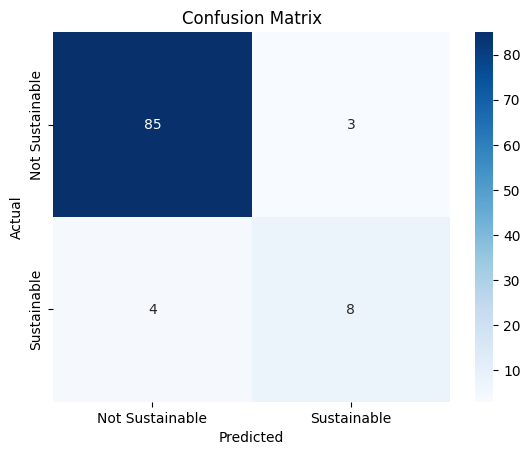

In [16]:
# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, cmap='Blues',
            xticklabels=['Not Sustainable', 'Sustainable'],
            yticklabels=['Not Sustainable', 'Sustainable'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [17]:
# Classification Report
print(classification_report(y_test, y_pred, target_names=['Not Sulestainable', 'Sustainab']))

                   precision    recall  f1-score   support

Not Sulestainable       0.96      0.97      0.96        88
        Sustainab       0.73      0.67      0.70        12

         accuracy                           0.93       100
        macro avg       0.84      0.82      0.83       100
     weighted avg       0.93      0.93      0.93       100



In [18]:
# Feature importance
coefficients = pd.DataFrame(model.coef_.T, index=X.columns, columns=['Coefficient'])
print(coefficients)

                    Coefficient
carbon_emissions      -0.023583
energy_output          0.000471
renewability_index     4.326728
cost_efficiency       -1.329506


In [19]:
import joblib
# Save the model to a file
joblib.dump(model, 'lrmodel_sustainable.pkl')

['lrmodel_sustainable.pkl']

In [20]:
# Load the dataset
data = pd.read_csv('Renewable_Energy_Adoption.csv')
data.head()

,carbon_emissions,energy_output,renewability_index,cost_efficiency,adoption
0,181.089042,728.345543,0.185133,2.835868,0
1,382.750007,582.486730,0.541901,2.656318,0
2,306.197880,378.574855,0.872946,0.615389,0
3,259.530469,832.415518,0.732225,2.035615,0
4,104.606524,716.258055,0.806561,2.210880,1


In [21]:
X = data[['carbon_emissions', 'energy_output', 'renewability_index', 'cost_efficiency']]
y = data['adoption']  # Target variable

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [23]:
# Initialize the model with a specified max depth to prevent overfitting
model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [24]:
y_pred = model.predict(X_test)
y_pred

array([0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1])

In [25]:
# Accuracy Score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.98


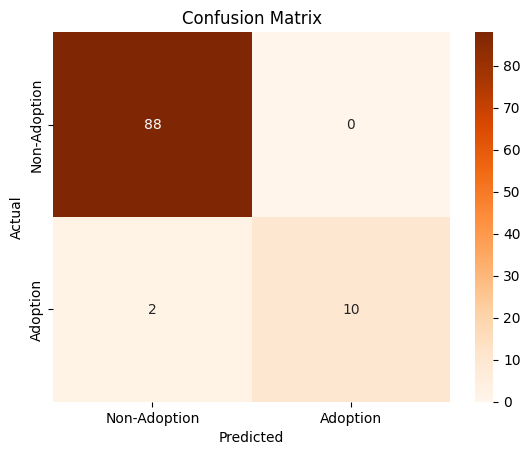

In [26]:
# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Non-Adoption', 'Adoption'],
            yticklabels=['Non-Adoption', 'Adoption'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [27]:
# Classification Report
print(classification_report(y_test, y_pred, target_names=['Non-Adoption', 'Adoption']))

              precision    recall  f1-score   support

Non-Adoption       0.98      1.00      0.99        88
    Adoption       1.00      0.83      0.91        12

    accuracy                           0.98       100
   macro avg       0.99      0.92      0.95       100
weighted avg       0.98      0.98      0.98       100



In [28]:
import joblib
# Save the model to a file
joblib.dump(model, 'Renewable_Energy_Adoption_model.pkl')

['Renewable_Energy_Adoption_model.pkl']

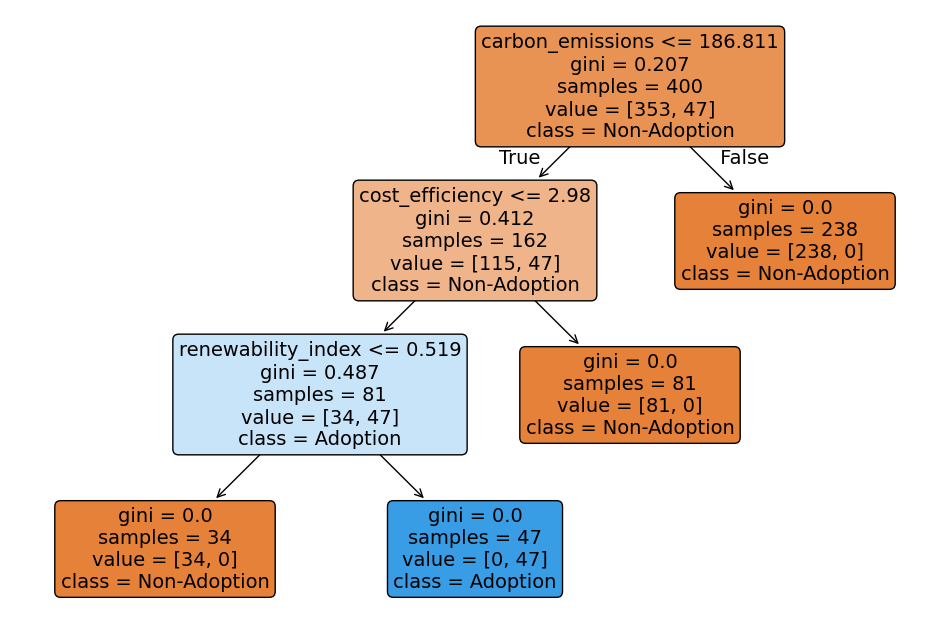

In [29]:
plt.figure(figsize=(12, 8))
plot_tree(model, feature_names=X.columns, class_names=['Non-Adoption', 'Adoption'], filled=True, rounded=True)
plt.savefig('dt1.png')
plt.show()

In [30]:
import gradio as gr
import joblib
import numpy as np

# Load trained Decision Tree model
model = joblib.load("Renewable_Energy_Adoption_model.pkl")

def predict_sustainability(carbon, energy, renewability, cost):
    input_data = np.array([[carbon, energy, renewability, cost]])
    prediction = model.predict(input_data)[0]

    if prediction == 1:
        return "✅ Sustainable Energy Adoption"
    else:
        return "❌ Not Sustainable"

interface = gr.Interface(
    fn=predict_sustainability,
    inputs=[
        gr.Number(label="Carbon Emissions (50 - 400)"),
        gr.Number(label="Energy Output (100 - 1000)"),
        gr.Slider(0, 1, step=0.01, label="Renewability Index"),
        gr.Number(label="Cost Efficiency (0.5 - 5)")
    ],
    outputs="text",
    title="🌍 Renewable Energy Adoption Predictor",
    description="AI Model to Predict Sustainable Energy Adoption"
)

interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://524ea953df53634943.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
